<a href="https://colab.research.google.com/github/23f1002879/Pytorch-Computer-Vision/blob/master/notebooks/05_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
from torchvision import models

In [3]:
weights =  models.ResNet18_Weights.DEFAULT # Inititating the RESNET18 weights

model = models.resnet18(weights=weights)  # Initiating the resnet18 architecture
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
# we don't want to retain the millions of parameter from the ResNet18 Since our FashionMNIST had only 10 classes
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True


In [5]:
# Replacing the final Layer of the ResNet_18 Architecture
nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(512,10)
)

for name, param in model.named_parameters():

    if param.requires_grad:
        print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


In [6]:
''' Since for our case the FashionMNIST data consist of only 1 channel and 28x28 Input features But ResNet_18 expect 3 channels 224x224 features. Therefore, there is need to transform the data '''


from torchvision import transforms, datasets

transform = transforms.Compose([
    transforms.Resize((
        224,
        224
    )),
    transforms.Grayscale(
        num_output_channels=3
    ),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
trainDataset = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

testDataset = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.55MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 51.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.2MB/s]


In [8]:
from torch.utils.data import DataLoader

trainLoader = DataLoader(
    trainDataset,
    batch_size=64,
    shuffle=True
)

testLoader = DataLoader(
    testDataset,
    batch_size=64,
    shuffle=False
)

In [9]:
device = torch.device(
'cuda' if torch.cuda.is_available() else 'cpu'
)

model=model.to(device)

In [10]:
# Setting Up the Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4
)

In [11]:
epoch = int(input("Enter the number of epochs:"))

for i in range(epoch):
  for image, label in trainLoader:
      image, label = image.to(device), label.to(device)
      output = model(image)
      loss = criterion(output, label)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
  print(loss.item())

Enter the number of epochs:3
0.23103897273540497
0.14557546377182007
0.04315681755542755


In [12]:
model.eval()

total, correct = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
  for image, label in testLoader:
    image, label = image.to(device), label.to(device)
    output = model(image)
    _, predicted = torch.max(output, 1)
    total += label.size(0)
    correct += (predicted == label).sum().item()
    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(label.cpu().numpy())

print(f"Accuracy: {100*correct/total}")

Accuracy: 92.14


In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [14]:
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[887   1  19  14   3   0  73   0   3   0]
 [  2 991   1   5   0   0   1   0   0   0]
 [ 23   0 892   7  34   0  44   0   0   0]
 [  9  14   8 911  26   0  31   0   1   0]
 [  0   0  52  18 888   0  41   0   1   0]
 [  0   0   0   0   0 991   0   4   0   5]
 [124   1  45  32  69   0 726   0   3   0]
 [  0   0   0   0   0  12   0 968   0  20]
 [  1   0   0   3   1   1   3   0 991   0]
 [  0   0   1   0   0   6   0  24   0 969]]


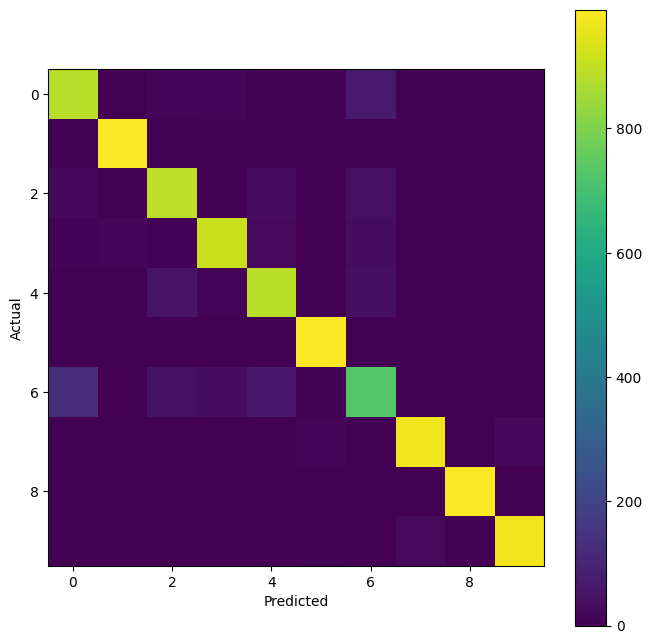

In [15]:
plt.figure(figsize=(8,8))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [16]:
print(
    classification_report(
        all_labels,
        all_preds
    )
)


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1000
           1       0.98      0.99      0.99      1000
           2       0.88      0.89      0.88      1000
           3       0.92      0.91      0.92      1000
           4       0.87      0.89      0.88      1000
           5       0.98      0.99      0.99      1000
           6       0.79      0.73      0.76      1000
           7       0.97      0.97      0.97      1000
           8       0.99      0.99      0.99      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

